7.	Using SVM algorithm, predict if a patient has a benign tumor or malignant tumor (cancer) based on the features provided. Use the following kernel for the SVM algorithm:

a) Linear 	b) Polynomial 		c) RBF 	d) Sigmoid

Find the following metrics for each of the SVM algorithms:

1) Accuracy 		2) Recall 		3) Precision 			4) F1-Score

5) Jaccard Score 	6) Error rates		7) Confusion Matrix

Compare all four SVM models using an ROC curve.

		Dataset: samples_cancer.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    jaccard_score, confusion_matrix, roc_curve, auc
)

In [ ]:
df = pd.read_csv('samples_cancer.csv')
df.head()

,ID,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [ ]:
df['BareNuc'] = pd.to_numeric(df['BareNuc'], errors='coerce')
df.dropna(inplace=True)

In [ ]:
df.drop(columns=['ID'], inplace=True)

In [ ]:
df['Class'] = df['Class'].map({2: 0, 4: 1})

In [ ]:
X = df.drop(columns=['Class'])
y = df['Class']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
metrics = {}

In [ ]:
for kernel in kernels:
    model = SVC(kernel=kernel, probability=True, random_state=42)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    metrics[kernel] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'Jaccard': jaccard_score(y_test, y_pred),
        'Error Rate': 1 - accuracy_score(y_test, y_pred),
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
        'FPR': fpr,
        'TPR': tpr,
        'AUC': roc_auc
    }

In [ ]:
for kernel, result in metrics.items():
    print(f"\nSVM Kernel: {kernel.upper()}")
    for key, value in result.items():
        if isinstance(value, (float, int)):
            print(f"{key}: {value:.3f}")
        elif key == 'Confusion Matrix':
            print(f"{key}:\n{value}")


SVM Kernel: LINEAR
Accuracy: 0.971
Recall: 0.948
Precision: 0.982
F1-Score: 0.965
Jaccard: 0.932
Error Rate: 0.029
Confusion Matrix:
[[78  1]
 [ 3 55]]
AUC: 0.998

SVM Kernel: POLY
Accuracy: 0.920
Recall: 0.810
Precision: 1.000
F1-Score: 0.895
Jaccard: 0.810
Error Rate: 0.080
Confusion Matrix:
[[79  0]
 [11 47]]
AUC: 0.999

SVM Kernel: RBF
Accuracy: 0.964
Recall: 0.948
Precision: 0.965
F1-Score: 0.957
Jaccard: 0.917
Error Rate: 0.036
Confusion Matrix:
[[77  2]
 [ 3 55]]
AUC: 0.997

SVM Kernel: SIGMOID
Accuracy: 0.956
Recall: 0.931
Precision: 0.964
F1-Score: 0.947
Jaccard: 0.900
Error Rate: 0.044
Confusion Matrix:
[[77  2]
 [ 4 54]]
AUC: 0.984


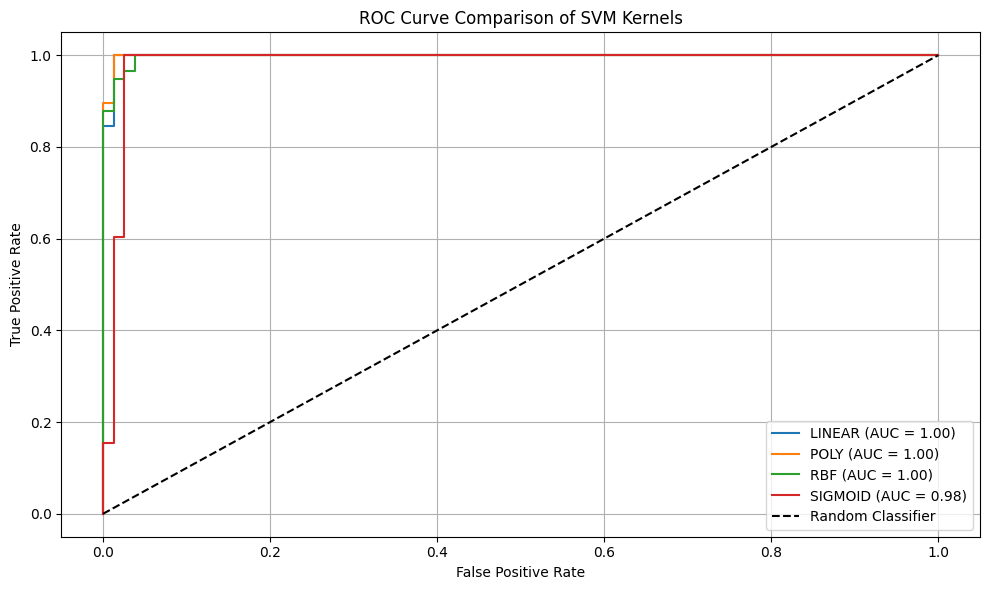

In [ ]:
plt.figure(figsize=(10, 6))
for kernel in kernels:
    plt.plot(metrics[kernel]['FPR'], metrics[kernel]['TPR'], label=f"{kernel.upper()} (AUC = {metrics[kernel]['AUC']:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title("ROC Curve Comparison of SVM Kernels")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()